Currently running N =  6


/tmp/ipykernel_14862/2697483366.py:65: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv("FI_time_resolved_N6_ratio0.75.dat", delim_whitespace=True, header=None)
/tmp/ipykernel_14862/2697483366.py:68: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv("FI_time_resolved_N6_ratio4.dat", delim_whitespace=True, header=None)


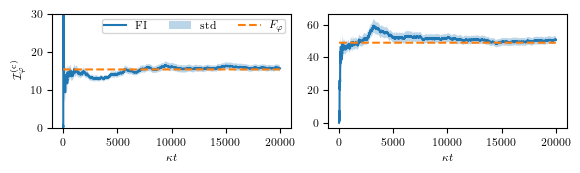

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import qutip as qt
import numpy as np
from scipy.sparse.linalg import eigs
from scipy.sparse import csr_matrix
from pathlib import Path
import matplotlib as mpl
from matplotlib import rc
rc('text', usetex=True)
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = "STIX"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["legend.borderpad"] = 0.15
mpl.rcParams["font.size"] = 8
#------------------------------------------------------------------------------#
ratios=[4, 0.75] # omega/omega_c values to iterate over
Ns=[6] # system sizes to iterate over
#------------------------------------------------------------------------------#
QFI = np.array([np.zeros(3)]) #initialize array to store data, each row
                                #corresponds to [N, omega/omega_c, QFI]
#------------------------------------------------------------------------------#
for N in Ns: # iterate over system sizes
    print('Currently running N = ', N)
    # system parameterss
    ddphi = 5*10**(-5) # small increment for phase shift for numerical derivatives
    omega_c = N/2 # critical frequency for given system size N
    # Collective spin operators for the sensor
    S_x = qt.jmat(N/2, 'x')
    S_y = qt.jmat(N/2, 'y')
    S_z = qt.jmat(N/2, 'z')
    S_p = qt.jmat(N/2, '+')
    S_m = qt.jmat(N/2, '-')
    idenJ = qt.qeye(S_z.shape[0])
#------------------------------------------------------------------------------#
    def deformed_L(omega, ddphi):
        """Function that builds the vectorized Lindblad Superoperator for the
        deformed Master Equation."""
        H = omega*S_x
        HT = (H.dag()).conj()
        SpSmT = ((S_p*S_m).dag()).conj()
        Lphi = (-1j*(qt.tensor(idenJ, H)-qt.tensor(HT, idenJ))
        -0.5*qt.tensor(idenJ, S_p*S_m)-0.5*qt.tensor(SpSmT, idenJ)
        +np.exp(-1j*(ddphi))*qt.tensor(S_m.conj(), S_m))
        return Lphi
#------------------------------------------------------------------------------#
    def dominant_eigval(L):
        """Function that diagonalizes a Master operator and returns its
        dominant eigenvalue."""
        evals = L.eigenenergies(sparse=True, sort='high', eigvals=1)
        return np.real(evals[0])
#------------------------------------------------------------------------------#
    for ratio in ratios: # iterate over omega/omega_c values
        omega = ratio*omega_c
        # Δφ + δφ, ω=beta*omega_c
        lambda_EP = dominant_eigval(deformed_L(omega,ddphi))
        # Δφ - δφ, ω=beta*omega_c
        lambda_EM = dominant_eigval(deformed_L(omega,-ddphi))
        QFI = np.append(QFI,[[N, ratio,-4*(lambda_EP+lambda_EM)/(ddphi*ddphi)]], 
                        axis=0)
#------------------------------------------------------------------------------#
fig , axs = plt.subplots(1,2,figsize=(1.65*3.54331,0.5*3.54331),
                                     width_ratios=[1,1], layout='tight')

df1 = pd.read_csv("FI_time_resolved_N6_ratio0.75.dat", delim_whitespace=True, header=None)
df1.columns = ["t", "FI", "std"]
df1 = df1[df1["t"] >= 0] # filter times < xx
df2 = pd.read_csv("FI_time_resolved_N6_ratio4.dat", delim_whitespace=True, header=None)
df2.columns = ["t", "FI", "std"]
df2 = df2[df2["t"] >= 0] # filter times < xx
axs[0].plot(df1["t"], df1["FI"]/df1["t"], label="FI")
axs[0].fill_between(df1["t"], (df1["FI"]-df1["std"])/df1["t"], (df1["FI"]+df1["std"])/df1["t"], alpha=0.3, label="std")
axs[0].plot(df1["t"], QFI[2][2]*np.ones(len(df1["t"])), label=r"$F_\varphi$", linestyle="dashed")
axs[0].set_xlabel(r"$\kappa t$")
axs[0].set_xscale("linear")
axs[0].set_ylabel(r"$\mathcal{I}^{(\mathrm{c})}_\varphi$")
axs[0].set_ylim([0,30])
axs[0].legend(ncols= 3)

axs[1].plot(df2["t"], df2["FI"]/df2["t"], label="FI")
axs[1].fill_between(df2["t"], (df2["FI"]-df2["std"])/df2["t"], (df2["FI"]+df2["std"])/df2["t"], alpha=0.3, label="std")
axs[1].plot(df2["t"], QFI[1][2]*np.ones(len(df2["t"])), label=r"$F_\varphi$", linestyle="dashed")
axs[1].set_xlabel(r"$\kappa t$")
axs[1].set_xscale("linear")

fig.savefig('FI_photocounting.pdf', dpi=1000)
plt.show()